In [91]:
import os
DIR_DATA = '/home/f.danilov/workflow/PAC_course2_2/PAC/laba5/data'
device = 'cpu'

1. Взять I том "Войны и мира" http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0040.shtml
2. Взять еще 7-10 любых (кроме Войны и мира) произведений http://az.lib.ru/t/tolstoj_lew_nikolaewich/, для каждого слова из I тома "Войны и мира" подсчитать TF-IDF
3. Обучить эмбеддинги на тексте I тома, вывести график loss
4. Взять из I тома top-15 слов по TF-IDF, найти к каждому top-3 ближайших слов из текста по косинусному расстоянию. Вывести и визуализировать через t-SNE выбранные и найденные слова.

In [92]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class CBOWDataset(Dataset):
    def __init__(self, data):
        self.contexts = []
        self.targets = []
        
        for context, target in data:
            self.contexts.append(context)
            self.targets.append(target)
    
    def __len__(self):
        return len(self.targets)
    
    def __getitem__(self, idx):
        return torch.tensor(self.contexts[idx], dtype=torch.long), torch.tensor(self.targets[idx], dtype=torch.long)

In [93]:
import re
from collections import Counter


def prepare_data_cbow(text: str, window_size=8, min_count = 1):
    
    # удаляем пунктуацию и цифры, оставляем только буквы
    text = ' '.join(word for word in text.split() if word.isalpha())
    text = re.sub(r'[^а-яё\s]', '', text.lower())
    
    import spacy

    nlp = spacy.load("ru_core_news_sm")
    # чтобы не было проблем с обработкой
    
    nlp.max_length = len(text) + 100000

    doc = nlp(text)
    
    excluded_pos = {
        'PRON',      # местоимения (я, ты, он, мой, твой)
        'ADP',       # предлоги (в, на, о, у)
        'CCONJ',     # сочинительные союзы (и, а, но, или)
        'SCONJ',     # подчинительные союзы (что, чтобы, если)
        'PART',      # частицы (не, бы, же, ли)
        'INTJ',      # междометия
        'AUX',       # вспомогательные глаголы
        'DET',       # определители (этот, тот, весь)
    }

    lemma_token = []
    for token in doc:
        # игнорируем пунктуацию и пробелы и части речи
        if not token.is_punct and not token.is_space and token.pos_ not in excluded_pos:
            lemma_token.append(token.lemma_.lower())

    
    word_counts_bad = Counter(lemma_token)
    # отсеиваем слова которых мало
    lemmas = [word for word in lemma_token if word_counts_bad[word] >= min_count]
    word_counts = Counter(lemmas)
    
    vocab = ['<PAD>'] + list(word_counts.keys())  # Добавляем PAD первым
    word_to_ix = {word: i for i, word in enumerate(vocab)}
    vocab_size = len(vocab)  # Теперь 0 = PAD, слова начинаются с 1
    
    # конвертируем леммы в индексы
    indices = [word_to_ix[word] for word in lemmas]
    
    # Формируем пары
    data = []
    for i, target_idx in enumerate(indices):
        context_indices = []
        
        start = max(0, i - window_size)
        end = min(len(indices), i + window_size + 1)
        
        for j in range(start, end):
            if i != j:
                context_indices.append(indices[j])
        
        if context_indices:  # если есть контекст
            data.append((context_indices, target_idx))
        
    # Создаем dataset
    dataset = CBOWDataset(data)
    
    return dataset, word_counts, len(lemma_token), vocab, word_to_ix

In [94]:
import pickle

def save_individual_books(book_datasets, save_dir):

    os.makedirs(save_dir, exist_ok=True)
    
    saved_files = []
    
    for book_name, book_data in book_datasets.items():
        safe_name = book_name.replace('.txt', '').replace(' ', '_').replace('/', '_')
        
        file_path = os.path.join(save_dir, f'{safe_name}.pkl')
        
        with open(file_path, 'wb') as f:
            pickle.dump(book_data, f)
        
        saved_files.append(file_path)
        print(f"{book_name} cохранен: {file_path}")
        
    return saved_files

In [95]:
def load_existing_books(save_dir):
    book_datasets = {}
    combined_data = []
    file_dir = os.listdir(save_dir)

    if os.path.exists(save_dir) and file_dir:
        for filename in file_dir:
            if filename.endswith('.pkl'):
                file_path = os.path.join(save_dir, filename)
                with open(file_path, 'rb') as f:
                    data = pickle.load(f)

                if not filename.startswith('combined_'):
                    book_name = filename.replace('.pkl', '').replace('_', ' ') + '.txt'
                    book_datasets[book_name] = data

                elif filename.startswith('combined_'):
                    combined_data = data
                
    
    return book_datasets, combined_data

In [96]:
import time

datas_path = os.listdir(DIR_DATA)
book_datasets = {}
all_words = []
save_dir = '/home/f.danilov/workflow/PAC_course2_2/PAC/laba5/model'

# загружаем сохраненные книги
book_datasets, combined_vocab = load_existing_books(save_dir)

# если нет сохраненных то обрабатываем
if not book_datasets and not combined_vocab: 
    os.makedirs(save_dir, exist_ok=True)

    for idx, book in enumerate(datas_path):
        print(f"\n[{idx+1}/{len(datas_path)}] Обработка: {book}")

        book_path = os.path.join(DIR_DATA, book)
        with open(book_path, 'r', encoding='windows-1251') as file:
                data = file.read()

        # замер времени
        start_time = time.time()
        dataset, word_counts, len_text, vocab, word_to_ix = prepare_data_cbow(data)
        elapsed = time.time() - start_time
        print(f"  Время обработки: {elapsed:.2f} сек")

        book_datasets[book] = {
            'dataset': dataset,
            'word_counts': word_counts,
            'len_text': len_text,
            'vocab': vocab,
            'word_to_ix': word_to_ix,
            'vocab_size': len(vocab),
            'num_samples': len(dataset),
        }

        all_words.extend(vocab)

    # сохраняю обработанные книги
    saved_files = save_individual_books(book_datasets, save_dir)

    # полный словарь из всех книг
    combined_vocab = list(set(all_words))
    combined_word_to_ix = {word: i for i, word in enumerate(combined_vocab)}
    
    # сохраняю весь обработанный словарь
    combined_path = os.path.join(save_dir, 'combined_vocab.pkl')
    with open(combined_path, 'wb') as f:
        pickle.dump({
            'vocab': combined_vocab,
            'word_to_ix': combined_word_to_ix,
            'vocab_size': len(combined_vocab)
        }, f)

print(f"\n{'='*50}")
print(f"Общий словарь: {len(combined_vocab)} слов")



[1/8] Обработка: Юность.txt
  Время обработки: 16.65 сек

[2/8] Обработка: Отрочество.txt
  Время обработки: 8.12 сек

[3/8] Обработка: Казаки.txt
  Время обработки: 14.92 сек

[4/8] Обработка: Холстмер.txt
  Время обработки: 4.59 сек

[5/8] Обработка: Два гусара.txt
  Время обработки: 6.17 сек

[6/8] Обработка: Детство.txt
  Время обработки: 10.73 сек

[7/8] Обработка: Поликушка.txt
  Время обработки: 6.20 сек

[8/8] Обработка: Война и мир. Книга 1.txt
  Время обработки: 74.52 сек
Юность.txt cохранен: /home/f.danilov/workflow/PAC_course2_2/PAC/laba5/model/Юность.pkl
Отрочество.txt cохранен: /home/f.danilov/workflow/PAC_course2_2/PAC/laba5/model/Отрочество.pkl
Казаки.txt cохранен: /home/f.danilov/workflow/PAC_course2_2/PAC/laba5/model/Казаки.pkl
Холстмер.txt cохранен: /home/f.danilov/workflow/PAC_course2_2/PAC/laba5/model/Холстмер.pkl
Два гусара.txt cохранен: /home/f.danilov/workflow/PAC_course2_2/PAC/laba5/model/Два_гусара.pkl
Детство.txt cохранен: /home/f.danilov/workflow/PAC_course

### 1. Для каждого слова из I тома "Войны и мира" подсчитать TF-IDF

In [117]:

def calculate_tfidf(book_datasets):
    avaible_books = []
    
    for book_name in book_datasets.keys():
        if book_name.startswith('Война'):
            war_peace_book = book_name
        else:
            avaible_books.append(book_name)
    
    war_data = book_datasets[war_peace_book]
    total_words_in_war = war_data['len_text']

    td_idf_words = {}
    for word in war_data['vocab']:
        count_word = war_data['word_counts'][word]
        tf_word = count_word / total_words_in_war

        blok = len(avaible_books)
        num_activ_books = sum(1 for book in avaible_books if word in book_datasets[book]['vocab'])

        idf_word = np.log10(blok / (num_activ_books + 1)) # чтобы в небыло /0

        td_idf_words[word] = tf_word * idf_word

    return td_idf_words, war_data


tfidf_scores, war_data = calculate_tfidf(book_datasets)

# топ-15 слов
if tfidf_scores:
    sorted_words = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=False)
    top_15 = sorted_words[:15]
    
    print(f"\n{'='*60}")
    print(f"Top-15 слов по TF-IDF")
    print(f"{'='*60}")
    for i, (word, score) in enumerate(top_15, 1):
        print(f"{i:2}. {word}: {score:.6f}")


Top-15 слов по TF-IDF
 1. сказать: -0.001039
 2. так: -0.000591
 3. мочь: -0.000512
 4. говорить: -0.000464
 5. ещё: -0.000379
 6. как: -0.000323
 7. лицо: -0.000293
 8. уже: -0.000246
 9. очень: -0.000237
10. рука: -0.000214
11. стать: -0.000214
12. теперь: -0.000210
13. опять: -0.000206
14. глаз: -0.000203
15. время: -0.000199


### 2. Обучить эмбеддинги на тексте I тома, вывести график loss

In [108]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, neg_samples=10, pad_idx=0):
        super(CBOWModel, self).__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.neg_samples = neg_samples
        self.pad_idx = pad_idx
        
        # Две матрицы эмбеддингов
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.target_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        
        # Инициализация весов
        torch.nn.init.xavier_uniform_(self.context_embeddings.weight)
        torch.nn.init.xavier_uniform_(self.target_embeddings.weight)        
        # Обнуляем PAD токен
        self.context_embeddings.weight.data[pad_idx] = 0
        self.target_embeddings.weight.data[pad_idx] = 0
    
    def forward(self, context_words, target_words):
        
        batch_size = context_words.size(0)
        context_emb = self.context_embeddings(context_words)  
        
        # Маскируем PAD
        mask = (context_words != self.pad_idx).float().unsqueeze(-1)
        context_emb = (context_emb * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  
        
        # положительные примеры
        target_emb = self.target_embeddings(target_words)  
        pos_score = torch.sum(context_emb * target_emb, dim=1)  
        pos_loss = -F.logsigmoid(pos_score).mean()
        
        # Отрицательные примеры
        negative_words = torch.randint(0, self.vocab_size,(batch_size, self.neg_samples))
        neg_emb = self.target_embeddings(negative_words)  
        neg_scores = torch.bmm(neg_emb, context_emb.unsqueeze(2)).squeeze(2) 
        neg_loss = -F.logsigmoid(-neg_scores).mean()
        
        loss = pos_loss + neg_loss
        
        return loss
    
    def get_context_embeddings(self):
        return self.context_embeddings.weight.data.cpu().numpy()
    
    def get_target_embeddings(self):
        return self.target_embeddings.weight.data.cpu().numpy()
    
    def get_embeddings(self):
        return self.get_context_embeddings(), self.get_target_embeddings()

In [109]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn_cbow(batch):
    contexts, targets = zip(*batch)
    
    # Конвертируем списки в тензоры и паддим
    contexts_padded = pad_sequence(
        [torch.tensor(ctx, dtype=torch.long) for ctx in contexts],
        batch_first=True,
        padding_value=0
    )
    
    targets_tensor = torch.tensor(targets, dtype=torch.long)
    return contexts_padded, targets_tensor

In [110]:
def save_checkpoint(filename, model, optimizer, epochs=[], train_losses=[], val_losses=[]):
    checkpoint = {
        'epochs': epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
    }
    torch.save(checkpoint, filename)

def load_checkpoint(filename, model, optimizer, device='cpu'):
    checkpoint = torch.load(filename, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    print(f"✓ Загружено из эпохи {len(checkpoint['epochs'])}, Train loss: {checkpoint['train_losses'][-1]:.4f}, Valid loss: {checkpoint['val_losses'][-1]:.4f}")
    return len(checkpoint['epochs']), checkpoint['epochs'], checkpoint['train_losses'], checkpoint['val_losses'],  optimizer

In [111]:
def train_test_split_cbow(dataset, train_ratio=0.8):
    train_size = int(len(dataset) * train_ratio)
    val_size = len(dataset) - train_size
    
    train_dataset, val_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size]
    )
    
    return train_dataset, val_dataset

In [112]:
def train_model_cbow(dataset, vocab_size, embedding_dim=100, epochs=20, batch_size=256, res_path = '/home/f.danilov/workflow/PAC_course2_2/PAC/laba5/learn/'):

    model = CBOWModel(vocab_size, embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) 
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    train_dataset, val_dataset = train_test_split_cbow(dataset)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,collate_fn=collate_fn_cbow)
    valid_dataloader = DataLoader(val_dataset, batch_size=int(batch_size/4), shuffle=True, collate_fn=collate_fn_cbow)
    

    start_epoch = 0
    train_losses = []
    best_loss = float('inf')
    epochs_list = []
    val_losses = []

    if res_path and os.path.exists(res_path+'checkpoint.pth'):
        print(f"Продолжаем обучение из {res_path}")
        start_epoch, epochs_list, train_losses, val_losses, optimizer = load_checkpoint(res_path + 'checkpoint.pth', model, optimizer)

    for epoch in range(start_epoch, epochs):
        train_loss = 0        
        valid_loss = 0

        # train step 
        for context_words, target_word in train_dataloader:
            model.zero_grad()
            loss = model(context_words, target_word)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()

        
        # valid step 
        model.eval()
        with torch.no_grad():
            for context_words, target_word in valid_dataloader:
                loss = model(context_words, target_word)
                valid_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        avg_val_loss = valid_loss / len(valid_dataloader)

        #scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        epochs_list.append(epoch)

        print(f"Epoch: {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Valid Loss: {avg_val_loss:.4f}")
        
        if (epoch + 1) % 5 == 0:
            save_checkpoint(res_path+'checkpoint.pth', model, optimizer, epochs_list, train_losses, val_losses)
        
        if avg_train_loss < best_loss:
            best_loss = avg_train_loss
            save_checkpoint(res_path+'checkpoint.pth', model, optimizer, epochs_list, train_losses, val_losses)
            torch.save(model.state_dict(), res_path + 'model_best.pth') 
        
    return model, epochs_list, train_losses, val_losses, optimizer

In [114]:
model, epochs_list, train_losses, val_losses, optimizer = train_model_cbow(
    dataset=war_data['dataset'],
    vocab_size=war_data['vocab_size'],
    embedding_dim=100,
    epochs=50,
    batch_size=512
)

/tmp/ipykernel_215200/3156829776.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  [torch.tensor(ctx, dtype=torch.long) for ctx in contexts],


Epoch: 1/50, Train Loss: 1.3205, Valid Loss: 1.1828
Epoch: 2/50, Train Loss: 1.1028, Valid Loss: 1.0690
Epoch: 3/50, Train Loss: 1.0475, Valid Loss: 1.0509
Epoch: 4/50, Train Loss: 1.0344, Valid Loss: 1.0454
Epoch: 5/50, Train Loss: 1.0294, Valid Loss: 1.0424
Epoch: 6/50, Train Loss: 1.0255, Valid Loss: 1.0389
Epoch: 7/50, Train Loss: 1.0231, Valid Loss: 1.0373
Epoch: 8/50, Train Loss: 1.0216, Valid Loss: 1.0388
Epoch: 9/50, Train Loss: 1.0208, Valid Loss: 1.0366
Epoch: 10/50, Train Loss: 1.0188, Valid Loss: 1.0374
Epoch: 11/50, Train Loss: 1.0195, Valid Loss: 1.0346
Epoch: 12/50, Train Loss: 1.0178, Valid Loss: 1.0355
Epoch: 13/50, Train Loss: 1.0176, Valid Loss: 1.0349
Epoch: 14/50, Train Loss: 1.0179, Valid Loss: 1.0360
Epoch: 15/50, Train Loss: 1.0179, Valid Loss: 1.0367
Epoch: 16/50, Train Loss: 1.0170, Valid Loss: 1.0363
Epoch: 17/50, Train Loss: 1.0167, Valid Loss: 1.0350
Epoch: 18/50, Train Loss: 1.0170, Valid Loss: 1.0364
Epoch: 19/50, Train Loss: 1.0168, Valid Loss: 1.0336
Ep

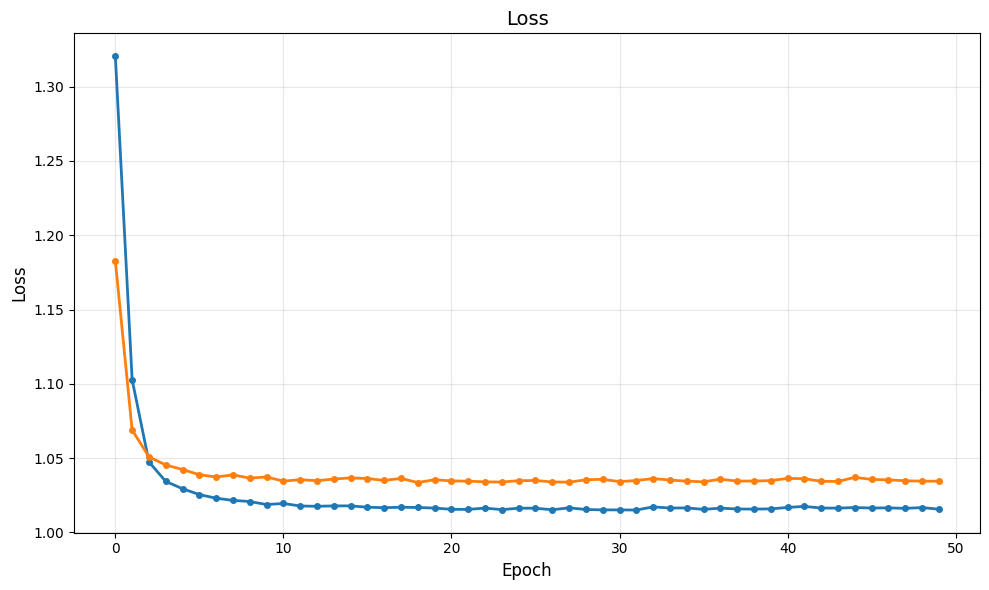

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, train_losses, marker='o', linewidth=2, markersize=4)
plt.plot(epochs_list, val_losses, marker='o', linewidth=2, markersize=4)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


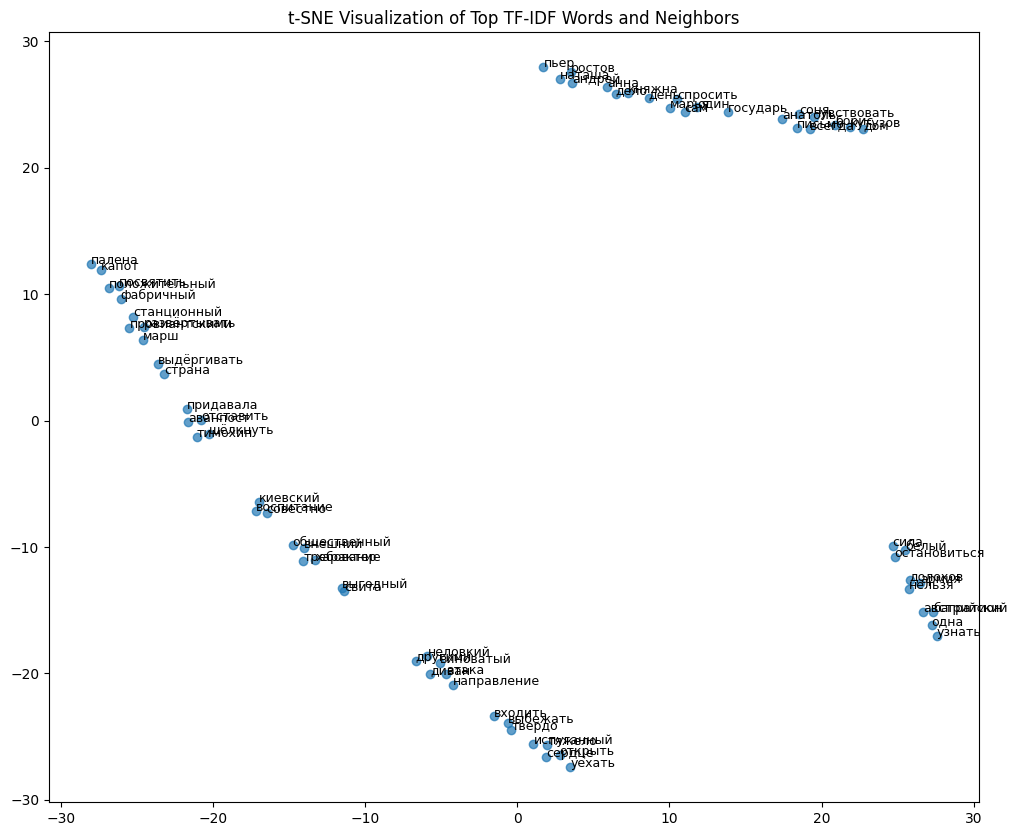

In [116]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

embeddings = model.get_context_embeddings()
vocab = war_data['vocab']
word_to_ix = war_data['word_to_ix']

top_15_words = [word for word, score in top_15]

# для каждого слова ищем 3 ближайших соседа по косинусному расстоянию
selected_indices = []
selected_words = []

# Нормализуем эмбеддинги для косинусного расстояния
# Добавляем epsilon чтобы избежать деления на ноль
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms = np.where(norms == 0, 1, norms)
norm_embeddings = embeddings / norms

# Дополнительно: заменяем любые NaN на 0
norm_embeddings = np.nan_to_num(norm_embeddings, nan=0.0)

for word in top_15_words:
    if word in word_to_ix:
        idx = word_to_ix[word]
        vec = norm_embeddings[idx].reshape(1, -1)
        
        # Считаем косинусное сходство со всеми словами
        sims = cosine_similarity(vec, norm_embeddings)[0]
        
        top_neighbors_idx = np.argsort(sims)[-4:] 
        
        for n_idx in top_neighbors_idx:
            if n_idx != idx and n_idx not in selected_indices:
                selected_indices.append(n_idx)
                selected_words.append(vocab[n_idx])
        
        # Добавляем само слово
        if idx not in selected_indices:
            selected_indices.append(idx)
            selected_words.append(word)

# Визуализация через t-SNE
if len(selected_indices) > 0:
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(selected_indices)-1))
    embeddings_selected = embeddings[selected_indices]
    tsne_results = tsne.fit_transform(embeddings_selected)

    plt.figure(figsize=(12, 10))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.7)

    # Подписываем слова
    for i, word in enumerate(selected_words):
        plt.annotate(word, (tsne_results[i, 0], tsne_results[i, 1]), fontsize=9)

    plt.title("t-SNE Visualization of Top TF-IDF Words and Neighbors")
    plt.show()
else:
    print("Не удалось найти слова для визуализации")